In [1]:
import json
import os
import clip
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from ollama import Client

from utils import dataset_utils
from datasets.mvtec_dataset import MVTecDataset
from datasets.realiad_dataset import RealIadDataset
from moviad.utilities.configurations import TaskType, LabelName

In [ ]:
client = Client(host="http://localhost:6000")
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
MODEL_NAME = "gemma3:12b"
categories = ["grid"]
dataset_path_mvtec = "/mnt/disk1/borsattifr/datasets/mvtec"
dataset_path_realiad = "/mnt/disk1/yfbenkhalifa/datasets/realiad/realiad_256"

## Create concept list

In [ ]:
def create_concept_list(dataset_path, dataset_type, categories):

    for category in categories:

        concepts = set()

        if dataset_type == "mvtec":
            train_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "train")
            train_dataset.load_dataset()

            test_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "test")
            test_dataset.load_dataset()

            dataset = pd.concat([train_dataset.samples, test_dataset.samples])
        
        elif dataset_type == "realiad":
            dataset = RealIadDataset(root = dataset_path, category=category)
            dataset.load_dataset()

        subset = dataset.samples.groupby("label", group_keys=False).sample(frac = 0.05, random_state = 42)
        print(f"Number of images to analyze: {len(subset)}")

        for i in range(len(subset)):
            sample = subset.iloc[i]
            concept_json = dataset_utils.first_vlm_query(category, MODEL_NAME, sample)
            concepts.update(c.lower() for c in concept_json)

        concepts = list(concepts)
        
        output_dir = f"concept_lists/original/{dataset_type}"
        os.makedirs(output_dir, exist_ok=True)

        with open(os.path.join(output_dir, f"{category}_concepts.json"), "w") as f:
            json.dump(concepts, f)

In [9]:
categories = ["mint"]

create_concept_list(dataset_path=dataset_path_realiad, dataset_type = "realiad", categories = categories)

Number of images to analyze: 265



## Inspect list

In [5]:
def number_of_concepts(category, dataset_type):
    path = f"concept_lists/original/{dataset_type}/{category}_concepts.json"
    with open(path, "r") as f:
        concepts = json.load(f)
    print(f"Original number of concepts for {category}:", len(concepts))
    return concepts

In [ ]:
original_hazelnut_concepts = number_of_concepts("hazelnut", "mvtec")
original_carpet_concepts = number_of_concepts("carpet", "mvtec")
original_screw_concepts = number_of_concepts("screw", "mvtec")
original_grid_concepts = number_of_concepts("grid", "mvtec")


Original number of concepts for hazelnut: 149
Original number of concepts for carpet: 161
Original number of concepts for screw: 229
Original number of concepts for grid: 223


In [6]:
original_mint_concepts = number_of_concepts("mint", "realiad")

Original number of concepts for mint: 203


### First step: query an LLM to aggregate logically similar concepts

In [7]:
def filter_concepts(concepts, category, dataset_type):

    message = "You are an industrial expert that is performing the task of visual anomaly detection."\
            f"Given the following list of visual concepts: {concepts}, related to images of a {category}, please group together those that refer to the same LITERAL meaning, i.e. if they share key words, spelling..."\
            "Ignore semantic relationships, focus only on literal wording and string similarity."\
            "Moreover, choose a representative attribute that best summarizes the group."\
            "I provide two examples: 1. 'Elliptical shape': ['ellipsoidal shape', 'ellipsoid shape', 'elliptical shape']"\
            "2. 'Smooth texture': ['natural texture, 'smooth texture', 'smooth surface texture', 'smooth appearance', 'organic texture', 'uniform texture', 'consistent texture']"\
            "DO NOT create groups that are too general, e.g. grouping together all colours or all textures. Representative concepts should still be able to clearly discriminate between normal and anomalous images."\
            "Return the output as a JSON dictionary where each key is the representative concept, and its value is the list of similar concepts grouped with it."\
            "In case of concepts that cannot be grouped with any other concept, the dictionary should have both as key and value the concept itself."\
            "Please, output ONLY the JSON dictionary."

    response = client.chat(model=MODEL_NAME, messages=[{"role": "user", "content": message}])

    try:
        concept_json = dataset_utils.extract_json(response["message"]["content"])
    except Exception as e:
        print(f"Error parsing response: {e}")
        concept_json = []
    
    print(f"Number of concepts extracted by the LLM for {category}:", len(concept_json))
    print(f"Extracted concepts for {category}:", concept_json.keys())

    with open(f"concept_lists/filtered/{dataset_type}/{category}_concepts.json", "w") as f:
        json.dump(concept_json, f)

In [8]:
filter_concepts(original_mint_concepts, "mint", "realiad")

Number of concepts extracted by the LLM for mint: 48
Extracted concepts for mint: dict_keys(['Circular form', 'Mint surface', 'Defined edges', 'Metallic surface', 'Embedded particulate', 'Foreign material inclusion', 'Dark spots', 'Color variation', 'Broken perimeter', 'Oval shape', 'Incomplete structure', 'Surface variation', 'Reduced overall size', 'Irregular outline', 'Embedded object', 'Surface inclusion', 'Concave impression', 'Rough texture', 'Localized debris', 'Compressed form', 'Surface deposit', 'Surface imperfection', 'Undercut area', 'Notched perimeter', 'Pale color', 'Broken surface', 'Visible debris', 'Dark inclusion', 'Irregular shadow', 'Green color', 'Uniform texture', 'Surface heterogeneity', 'Contaminant speck', 'Contaminant particles', 'Irregular distribution', 'Round edge', 'Fragment absence', 'Opaque spot', 'Irregular perimeter', 'Abrasive mark', 'Broken piece', 'Circular markings', 'Uneven profile', 'Circular indentations', 'Discoloration', 'Uniform color distrib

### Second step: filter concept list

In [9]:
def load_concepts(category, dataset_type):
    with open(f"concept_lists/filtered/{dataset_type}/{category}_concepts.json", "r") as f:
        filtered_concepts = json.load(f)

    final_concepts = list(filtered_concepts.keys())

    return final_concepts

In [10]:
final_mint_concepts = load_concepts("mint", "realiad")

In [11]:
#remove concepts with high cosine similarity
def compute_concept_similarity(model, concepts, threshold = 0.9):
    model.eval()
    model.to("cpu")
    with torch.no_grad():
        text_tokens = clip.tokenize(concepts).to("cpu")
        text_features = model.encode_text(text_tokens)
    
        #normalize features
        text_features /= text_features.norm(dim = -1, keepdim = True)

    #compute cosine similarity between pairs
    similarities = (text_features @ text_features.T).cpu().numpy()
    np.fill_diagonal(similarities, 0.0) #ignore self-similarity

    high_sim_counts = (similarities > threshold).sum(axis = 1)

    print("\nHigh similarity pairs (> 0.9):")
    for i in range(len(concepts)):
        for j in range(i + 1, len(concepts)):
            sim = similarities[i, j]
            if sim > threshold:
                print(f"{concepts[i]} ↔ {concepts[j]}: {sim:.4f}")

    #remove concepts with more than two high-similarity matches
    concepts_to_remove = set(np.array(concepts)[high_sim_counts >= 2])

    #for remaining pairs, remove one of each
    remaining_idx = [i for i, c in enumerate(concepts) if c not in concepts_to_remove]
    remaining_concepts = [concepts[i] for i in remaining_idx]
    remaining_similarities = similarities[np.ix_(remaining_idx, remaining_idx)]

    #track which indices to drop
    already_removed = set()
    for i in range(len(remaining_idx)):
        for j in range(i + 1, len(remaining_idx)):
            if remaining_similarities[i, j] > threshold:
                if remaining_concepts[i] not in already_removed and remaining_concepts[j] not in already_removed:
                    already_removed.add(remaining_concepts[i])
    
    all_removed = concepts_to_remove.union(already_removed)

    final_concepts = [c for c in remaining_concepts if c not in already_removed]
    print("Concepts removed:", all_removed)
    print("Number of concepts kept:", len(final_concepts))

    return final_concepts

In [12]:
model, preprocess = clip.load("ViT-B/32", jit = False)

final_mint_concepts = compute_concept_similarity(model, final_mint_concepts)


High similarity pairs (> 0.9):
Circular form ↔ Circular indentations: 0.9106
Defined edges ↔ Round edge: 0.9033
Color variation ↔ Surface variation: 0.9043
Broken perimeter ↔ Notched perimeter: 0.9224
Broken perimeter ↔ Irregular perimeter: 0.9248
Broken perimeter ↔ Broken piece: 0.9004
Surface variation ↔ Surface imperfection: 0.9062
Surface variation ↔ Broken surface: 0.9058
Surface variation ↔ Surface heterogeneity: 0.9238
Irregular outline ↔ Irregular distribution: 0.9116
Surface inclusion ↔ Surface imperfection: 0.9146
Surface inclusion ↔ Surface heterogeneity: 0.9087
Rough texture ↔ Uniform texture: 0.9033
Localized debris ↔ Visible debris: 0.9297
Surface imperfection ↔ Broken surface: 0.9131
Surface imperfection ↔ Surface heterogeneity: 0.9155
Notched perimeter ↔ Irregular perimeter: 0.9243
Broken surface ↔ Fragment absence: 0.9033
Broken surface ↔ Broken piece: 0.9453
Dark inclusion ↔ Discoloration: 0.9077
Contaminant speck ↔ Contaminant particles: 0.9194
Concepts removed: {'D

In [13]:
## remove concepts that have a high cosine similarity with the class ("anomalous") or the category
def compute_class_similarity(model, concepts, category, classes = ["anomalous", "normal"], threshold = 0.9):
    references = [category] + classes

    with torch.no_grad():
        ref_tokens = clip.tokenize(references).to("cpu")
        ref_features = model.encode_text(ref_tokens)
        ref_features = ref_features / ref_features.norm(dim = -1, keepdim = True)

        text_tokens = clip.tokenize(concepts).to("cpu")
        text_features = model.encode_text(text_tokens)
        text_features /= text_features.norm(dim = -1, keepdim = True)
    
    similarities = (text_features @ ref_features.T).cpu().numpy()

    concepts_to_remove = set()
    for i, concept in enumerate(concepts):
        for j, ref in enumerate(references):
            sim = similarities[i, j]
            if sim > threshold:
                concepts_to_remove.add(concept)
                print(f"{concept} — high similarity to '{ref}': {sim:.4f}")
                break  
    
    final_concepts = [c for c in concepts if c not in concepts_to_remove]
    print("Number of concepts kept:", len(final_concepts))
    return final_concepts

In [14]:
final_mint_concepts = compute_class_similarity(model, final_mint_concepts, "mint")

Mint surface — high similarity to 'mint': 0.9233
Number of concepts kept: 31


In [15]:
with open(f"concept_lists/filtered/realiad/mint_concepts.json", "w") as f:
        json.dump(final_mint_concepts, f)


## Final Dataset creation

### 1st strategy: VLM prompting

In [3]:
with open(f"concept_lists/filtered/realiad/mint_concepts.json", "r") as f:
    final_mint_concepts = json.load(f)

In [4]:
from tqdm import tqdm

def create_final_dataset(dataset_path, dataset_type, category, final_concepts):
    image_concepts = []

    if dataset_type == "mvtec":
        train_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "train")
        train_dataset.load_dataset()

        test_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "test")
        test_dataset.load_dataset()

        samples = pd.concat([train_dataset.samples, test_dataset.samples])
    
    elif dataset_type == "realiad":
        dataset = RealIadDataset(root = dataset_path, category=category)
        dataset.load_dataset()
        samples = dataset.samples

    for i in tqdm(range(len(samples))):
        sample = samples.iloc[i]
        concept_vector = dataset_utils.second_vlm_query(category, MODEL_NAME, sample, final_concepts)
        image_concepts.append(concept_vector)

    concepts_df = pd.DataFrame(image_concepts, columns = [f"{c}" for c in final_concepts])
    final_df = pd.concat([samples.reset_index(drop=True), concepts_df], axis=1)

    # for i in range(len(anomalous_samples)):
    #     sample = anomalous_samples.iloc[i]
    #     concept_vector_anomalous = dataset_utils.second_vlm_query(category, MODEL_NAME, sample, final_concepts, anomalous = True)
    #     anomalous_images_concepts.append(concept_vector_anomalous)

    # anomalous_concepts_df = pd.DataFrame(anomalous_images_concepts, columns = [f"{c}" for c in final_concepts])
    # anomalous_samples = pd.concat([anomalous_samples.reset_index(drop=True), anomalous_concepts_df], axis = 1)
    # print("End of anomalous images") 

    # final_df = pd.concat([normal_samples, anomalous_samples], ignore_index = True)

    save_path = f"/mnt/disk1/arianna_stropeni/cbm_data/{dataset_type}/{category}_dataset_automated.csv"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    final_df.to_csv(save_path, index = False)
    return final_df

In [5]:
create_final_dataset(dataset_path = dataset_path_realiad, dataset_type = "realiad", category = "mint", final_concepts = final_mint_concepts)

100%|██████████| 5305/5305 [6:48:06<00:00,  4.62s/it]  


,image_path,label,label_index,mask_path,Metallic surface,Embedded particulate,Foreign material inclusion,Dark spots,Color variation,Oval shape,...,Fragment absence,Opaque spot,Abrasive mark,Circular markings,Uneven profile,Circular indentations,Discoloration,Uniform color distribution,Surface obstruction,Solid form
0,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,missing parts,1,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,1,0,0,0,0,0,...,1,0,0,1,0,1,0,0,0,1
1,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,missing parts,1,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,0,0,0,0,0,0,...,1,0,0,1,1,1,0,0,0,1
2,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,missing parts,1,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,0,0,0,0,0,0,...,1,0,0,1,1,1,0,0,0,1
3,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,missing parts,1,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,0,0,0,0,0,0,...,1,0,0,1,1,1,0,0,0,1
4,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,missing parts,1,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,1,0,0,0,0,0,...,1,1,0,1,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5300,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,good,0,,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,1
5301,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,good,0,,0,0,0,0,0,0,...,1,0,0,1,0,1,0,1,0,1
5302,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,good,0,,0,0,0,0,0,0,...,1,0,0,1,0,1,0,1,0,1
5303,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,good,0,,0,0,0,0,0,0,...,1,0,0,1,0,1,0,1,0,1


### 2nd Strategy: CLIP

In [44]:
model, preprocess = clip.load("ViT-B/32", jit = False)

In [45]:
### function to use CLIP on an image
def extract_concepts_with_clip(model, preprocess, df, concepts, category, threshold = 0.2):
    model.eval()
    model.to("cpu")
    text_inputs = torch.cat([clip.tokenize(f"a {category} with a {c}") for c in concepts]).to("cpu")

    concept_rows = []

    for i, row in df.iterrows():
        image_path = row["image_path"]
        image = Image.open(image_path).convert("RGB")
        image_input = preprocess(image).unsqueeze(0).to("cpu")
        #calculate features
        with torch.no_grad():
            image_features = model.encode_image(image_input)
            text_features = model.encode_text(text_inputs)
    
        #normalize features
        image_features /= image_features.norm(dim = -1, keepdim = True)
        text_features /= text_features.norm(dim = -1, keepdim = True)

        #compute similarity between image and text features
        similarities = (100.0 * image_features @ text_features.T).softmax(dim = -1)
        probabilities = similarities[0].tolist()

        concept_presence = {concept: int(prob > threshold) for concept, prob in zip(concepts, probabilities)}
        concept_rows.append(concept_presence)
    
    concept_df = pd.DataFrame(concept_rows)
    
    for col in concept_df.columns:
        df[col] = concept_df[col]
    
    df.to_csv(f"/mnt/disk1/arianna_stropeni/cbm_data/mvtec/{category}_dataset_clip.csv", index = False)

In [46]:
path_hazelnut = "/mnt/disk1/arianna_stropeni/cbm_data/mvtec/hazelnut_dataset.csv"
hazelnut_df = pd.read_csv(path_hazelnut)

final_hazelnut_concepts = [col for col in hazelnut_df.columns if col not in ["split", "anomaly_type", "image_path", "label_index", "mask_path"]]

extract_concepts_with_clip(model, preprocess, hazelnut_df, final_hazelnut_concepts, category = "hazelnut")


### Split the dataset

In [3]:
def read_csv(path):
    final_df = pd.read_csv(path)
    return final_df

In [13]:
grid_df = read_csv('/mnt/disk1/arianna_stropeni/cbm_data/mvtec/grid_dataset_automated.csv')

In [14]:
def adjust_columns(df):
    #define the anomaly type
    if "label" in df.columns:
        df = df.rename(columns={"label": "anomaly_type"})

    #drop unnecessary columns
    if "split" in df.columns and "path" in df.columns:
        df = df.drop(columns = ["path", "split"])

    return df

In [15]:
grid_df = adjust_columns(grid_df)

In [23]:
def split_dataframe(df, train_size = 0.8, test_size = 0.5):   
    train_df, val_test_df = train_test_split(df, train_size = train_size, stratify=df["anomaly_type"], shuffle = True)

    val_df, test_df = train_test_split(val_test_df, test_size=test_size, shuffle = True)

    train_df["split"] = "train"
    val_df["split"] = "val"
    test_df["split"] = "test"

    df = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

    summary = df.groupby(["anomaly_type", "split"]).size().unstack(fill_value=0)
    print(summary)

    return df

In [28]:
grid_df = split_dataframe(grid_df)

split                test  train  val
anomaly_type                         
bent                    1     10    1
broken                  1      9    2
glue                    1      9    1
good                   29    227   29
metal_contamination     1      9    1
thread                  2      9    0


In [29]:
grid_df.to_csv('/mnt/disk1/arianna_stropeni/cbm_data/mvtec/grid_dataset_automated.csv')

### Remove uninformative concepts

In [69]:
with open(f"concept_lists/filtered/grid_concepts.json", "r") as f:
    final_grid_concepts = json.load(f)

In [ ]:
def drop_concepts(df, concepts, num_images):
    existing_concepts = [col for col in concepts if col in df.columns]
    #drop concepts that appear in less than 10 images
    invalid_concepts = df[existing_concepts].sum()[lambda x: x < 10].index
    print("Concepts that appear in less than 10 images:", invalid_concepts)

    df = df.drop(columns=invalid_concepts)

    remaining_concepts = [col for col in existing_concepts if col not in invalid_concepts]
    #drop concepts that appear in more than 95% of the images
    always_present_concepts = df[remaining_concepts].sum()[lambda x: x > num_images * 0.95].index
    print("Concepts that appear in more than 95% of images:", always_present_concepts)

    df = df.drop(columns=always_present_concepts)

    remained_concepts = [col for col in concepts if col in df.columns]

    return df, remained_concepts

In [75]:
grid_df, remained_grid_concepts = drop_concepts(grid_df, final_grid_concepts, num_images=len(grid_df))

Concepts that appear in less than 10 images: Index([], dtype='object')
Concepts that appear in more than 95% of images: Index([], dtype='object')


In [85]:
grid_df.to_csv('/mnt/disk1/arianna_stropeni/cbm_data/mvtec/grid_dataset_automated.csv', index = False)

In [86]:
grid_df = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/grid_dataset_automated.csv")

In [65]:
grid_df

,anomaly_type,image_path,label_index,mask_path,raised area,localized accumulation,discontinuous line,fractured element,segmentation fault,gap in pattern,...,uneven distribution,mesh appearance,detached strand,fiber displacement,line deviation,fracture,altered form,altered boundary,altered stain,split
0,good,/mnt/disk1/borsattifr/datasets/mvtec/grid/trai...,0,NaN,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,train
1,good,/mnt/disk1/borsattifr/datasets/mvtec/grid/trai...,0,NaN,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,train
2,good,/mnt/disk1/borsattifr/datasets/mvtec/grid/trai...,0,NaN,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,train
3,glue,/mnt/disk1/borsattifr/datasets/mvtec/grid/test...,1,/mnt/disk1/borsattifr/datasets/mvtec/grid/grou...,1,1,0,0,0,1,...,1,1,0,0,0,0,1,1,0,train
4,good,/mnt/disk1/borsattifr/datasets/mvtec/grid/trai...,0,NaN,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337,good,/mnt/disk1/borsattifr/datasets/mvtec/grid/trai...,0,NaN,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,test
338,good,/mnt/disk1/borsattifr/datasets/mvtec/grid/trai...,0,NaN,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,test
339,good,/mnt/disk1/borsattifr/datasets/mvtec/grid/trai...,0,NaN,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,test
340,good,/mnt/disk1/borsattifr/datasets/mvtec/grid/trai...,0,NaN,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,test


### Remove highly correlated concepts

In [ ]:
def compute_correlation(df, concepts, threshold = 0.9):
    concepts_to_use = [col for col in concepts if col in df.columns]
    correlation_matrix = df[concepts_to_use].corr().abs()

    plt.figure(figsize=(18, 15))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
    plt.show()

    upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] >= threshold)]

    print(f"Concepts with correlation >= {threshold}: {to_drop}")

    df = df.drop(columns = to_drop)

    return df

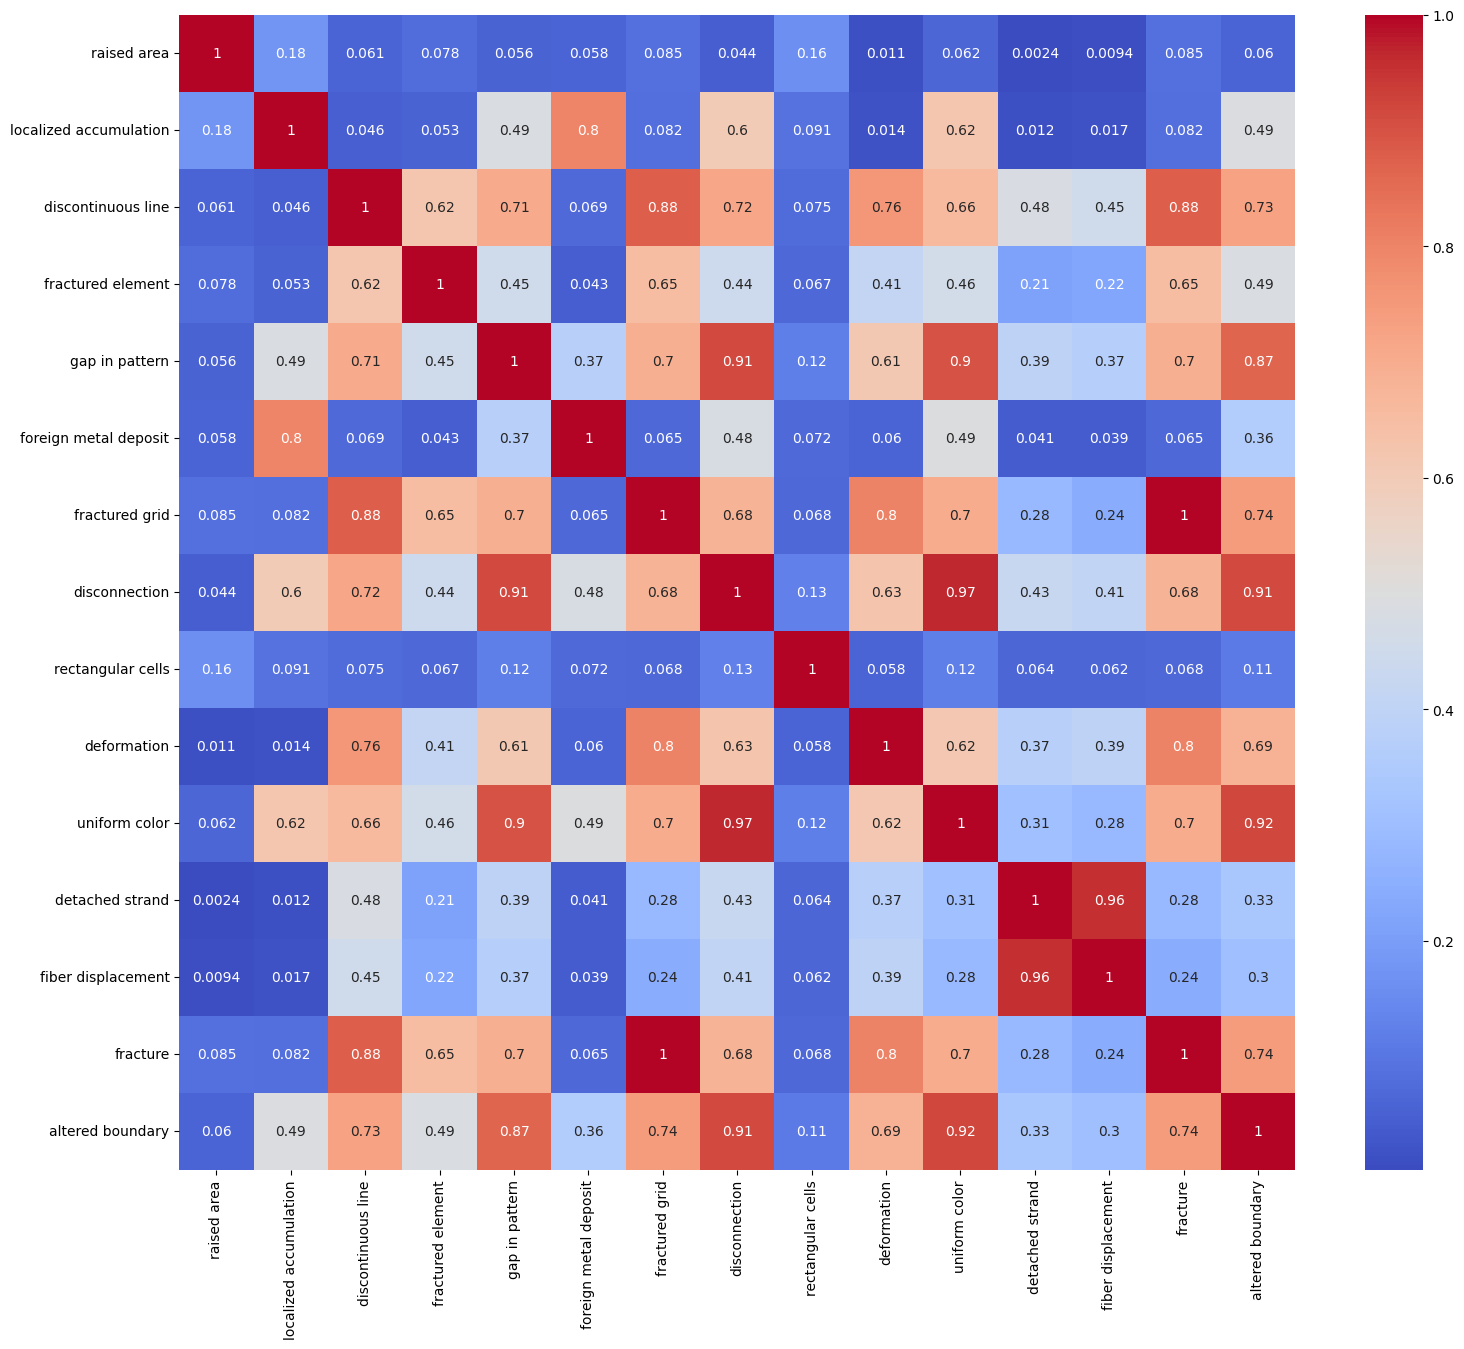

Concepts with correlation >= 0.9: ['disconnection', 'uniform color', 'fiber displacement', 'fracture', 'altered boundary']


In [36]:
grid_df = compute_correlation(grid_df, remained_grid_concepts)

In [99]:
carpet_df.to_csv(f"/mnt/disk1/arianna_stropeni/cbm_data/mvtec/carpet_dataset.csv")
final_carpet_concepts = [col for col in final_carpet_concepts if col in carpet_df.columns]
print("Number of final concepts:", len(final_carpet_concepts))

Number of final concepts: 21


## (Optional) Manually check concept annotation

In [100]:
final_carpet_concepts

['Hole',
 'Dark Area',
 'Color Variation',
 'Fiber Protrusion',
 'Metallic Sheen',
 'Uneven Distribution',
 'Lighter Area',
 'Irregular Shape',
 'Unraveling',
 'Texture Disruption',
 'Chromatic Anomaly',
 'Shadowed Area',
 'Spotty Appearance',
 'Rectangular Pattern',
 'Detached Fiber',
 'Damaged Fiber',
 'Neutral Color',
 'Isolated Patch',
 'Discoloration',
 'Pattern Disruption',
 'Short Fibers']

In [106]:
#automatically exclude anomalous concepts
anomalous_concepts = ['Dark Area', 'Uneven Distribution', 'Color Variation', 'Fiber Protrusion', 'Hole', 'Metallic Sheen', 'Unraveling', 'Texture Disruption', 'Chromatic Anomaly', 'Pattern Disruption', 'Detached Fiber', 'Damaged Fiber']

carpet_df.loc[carpet_df["label_index"] == 0, anomalous_concepts] = 0

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image as PILImage
import ipywidgets as widgets
import os


# --- Define editable features ---
editable_columns = [col for col in carpet_df.columns if col not in ["image_path", "split", "label", "mask_path", "path"]]


def show_image(index):
    print(f"Rendering index {index}")
    row = carpet_df.iloc[index]

    img = PILImage.open(row["image_path"])
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {row['label_index']}")
    plt.show()

    # Create input widgets for each editable feature
    editors = {}
    for col in editable_columns:
        value = row[col]
        if isinstance(value, (int, float)):
            editor = widgets.FloatText(value=value, description=col)
        else:
            editor = widgets.Text(value=str(value), description=col)
        editors[col] = editor

    # Button to save edits
    save_button = widgets.Button(description="Save Changes", button_style='success')

    def save_changes(b):
        for col, widget in editors.items():
            carpet_df.at[index, col] = widget.value
        print(f"✅ Changes saved for index {index}")

    save_button.on_click(save_changes)

    # Display form
    display(widgets.VBox(list(editors.values()) + [save_button]))


# Interface to scroll through samples
widgets.interact(show_image, index=widgets.IntSlider(min=0, max=len(carpet_df)-1, step=1))

interactive(children=(IntSlider(value=0, description='index', max=396), Output()), _dom_classes=('widget-inter…

<function __main__.show_image(index)>

In [109]:
carpet_df.to_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/carpet_dataset.csv", index = False)

## (Done) Create complete dataset

In [ ]:
#mvtec dataset
categories = ["bottle", "cable", "capsule", "carpet", "grid", "hazelnut", "leather", "metal_nut", "pill", "screw", "tile", "toothbrush", "transistor", "wood", "zipper"]
full_dataset_mvtec = pd.DataFrame()

for category in categories:
    for split in ["train", "test"]:
        partial_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path_mvtec, category = category, split = split)
        partial_dataset.load_dataset()
        partial_dataset.samples["category"] = category

        full_dataset_mvtec = pd.concat([full_dataset_mvtec, partial_dataset.samples], ignore_index=True)

full_dataset_mvtec = full_dataset_mvtec.reset_index(drop=True)

In [6]:
#real-iad dataset
categories = ["switch", "u_block", "usb", "woodstick", "rolled_strip_base", "toy", "eraser", "usb_adaptor", "fire_hood", "regulator", "porcelain_doll", "toothbrush", "wooden_beads", "button_battery", "mounts",
              "plastic_nut", "pcb", "end_cap", "phone_battery", "bottle_cap", "mint", "toy_brick", "plastic_plug", "zipper", "audiojack", "terminalblock", "tape", "transistor1", "sim_card_set", "vcpill"]
full_dataset_realiad = pd.DataFrame()

for category in categories:
    partial_dataset = RealIadDataset(root = dataset_path_realiad, category=category)
    print(f"Loading {category} dataset...")
    partial_dataset.load_dataset()
    partial_dataset.samples["category"] = category
    full_dataset_realiad = pd.concat([full_dataset_realiad, partial_dataset.samples], ignore_index=True)

full_dataset_realiad = full_dataset_realiad.reset_index(drop=True)

Loading switch dataset...


Loading u_block dataset...
Loading usb dataset...
Loading woodstick dataset...
Loading rolled_strip_base dataset...
Loading toy dataset...
Loading eraser dataset...
Loading usb_adaptor dataset...
Loading fire_hood dataset...
Loading regulator dataset...
Loading porcelain_doll dataset...
Loading toothbrush dataset...
Loading wooden_beads dataset...
Loading button_battery dataset...
Loading mounts dataset...
Loading plastic_nut dataset...
Loading pcb dataset...
Loading end_cap dataset...
Loading phone_battery dataset...
Loading bottle_cap dataset...
Loading mint dataset...
Loading toy_brick dataset...
Loading plastic_plug dataset...
Loading zipper dataset...
Loading audiojack dataset...
Loading terminalblock dataset...
Loading tape dataset...
Loading transistor1 dataset...
Loading sim_card_set dataset...
Loading vcpill dataset...


In [8]:
full_dataset_realiad["stratify_key"] = full_dataset_realiad["category"].astype(str) + "_" + full_dataset_realiad["label_index"].astype(str)

In [9]:
from sklearn.model_selection import train_test_split

train_df, val_test_df = train_test_split(full_dataset_realiad, test_size=0.1, stratify=full_dataset_realiad["stratify_key"], shuffle = True)

val_df, test_df = train_test_split(val_test_df, test_size=0.5, stratify = val_test_df["stratify_key"], shuffle = True)

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

full_dataset_realiad = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

In [18]:
full_dataset_realiad['category_index'] = full_dataset_realiad['category'].astype('category').cat.codes

In [20]:
full_dataset_realiad.to_csv("/mnt/disk1/arianna_stropeni/cbm_data/realiad/full_dataset.csv", index = False)

In [19]:
full_dataset_realiad

,image_path,anomaly_type,label_index,mask_path,category,split,category_index
0,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,good,0,,phone_battery,train,9
1,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,pit,1,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,mounts,train,7
2,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,good,0,,mounts,train,7
3,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,good,0,,terminalblock,train,18
4,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,contamination,1,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,end_cap,train,3
...,...,...,...,...,...,...,...
151045,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,good,0,,zipper,test,29
151046,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,pit,1,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,plastic_plug,test,11
151047,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,good,0,,sim_card_set,test,15
151048,/mnt/disk1/yfbenkhalifa/datasets/realiad/reali...,good,0,,audiojack,test,0


## Analysis of concepts

### Discriminative analysis


In [110]:
cropped_carpet_df = carpet_df.iloc[:60]

In [44]:
#chi square test
def chi_square_test(df, concepts):
    for col in concepts:
        contingency = pd.crosstab(df[col], df["label_index"])
        chi2, p, dof, ex = chi2_contingency(contingency)
        print(f"{col}: p-value = {p:.2e}")
        prob_anomalous = df[df["label_index"] == 1][col].mean()
        prob_normal = df[df["label_index"] == 0][col].mean()
        print(f"{col}: P(concept=1 | anomaly) = {prob_anomalous:.2f}, P(concept=1 | normal) = {prob_normal:.2f}")

In [45]:
chi_square_test(grid_df, remained_grid_concepts)

raised area: p-value = 5.07e-01
raised area: P(concept=1 | anomaly) = 0.39, P(concept=1 | normal) = 0.33
localized accumulation: p-value = 2.95e-27
localized accumulation: P(concept=1 | anomaly) = 0.40, P(concept=1 | normal) = 0.00
discontinuous line: p-value = 7.55e-39
discontinuous line: P(concept=1 | anomaly) = 0.56, P(concept=1 | normal) = 0.00
fractured element: p-value = 4.48e-15
fractured element: P(concept=1 | anomaly) = 0.23, P(concept=1 | normal) = 0.00
gap in pattern: p-value = 9.35e-63
gap in pattern: P(concept=1 | anomaly) = 0.91, P(concept=1 | normal) = 0.01
foreign metal deposit: p-value = 1.86e-17
foreign metal deposit: P(concept=1 | anomaly) = 0.26, P(concept=1 | normal) = 0.00
fractured grid: p-value = 6.51e-35
fractured grid: P(concept=1 | anomaly) = 0.51, P(concept=1 | normal) = 0.00
disconnection: p-value = 8.49e-75
disconnection: P(concept=1 | anomaly) = 1.00, P(concept=1 | normal) = 0.00
rectangular cells: p-value = 3.80e-02
rectangular cells: P(concept=1 | anoma

In [47]:
grid_df = pd.read_csv('/mnt/disk1/arianna_stropeni/cbm_data/mvtec/grid_dataset_automated.csv')

### Check differences between fully automated dataset and partially automated dataset

In [47]:
hazelnut_df = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/hazelnut_dataset.csv")
hazelnut_df_automated = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/hazelnut_dataset_automated.csv")
hazelnut_df_clip = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/hazelnut_dataset_clip.csv")

In [48]:
final_hazelnut_concepts = [col for col in hazelnut_df.columns if col not in ["split", "anomaly_type", "image_path", "label_index", "mask_path"]]

In [57]:
carpet_df = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/carpet_dataset.csv")
carpet_df_automated = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/carpet_dataset_automated.csv")

In [61]:
cropped_carpet_df = carpet_df.iloc[:60]
cropped_carpet_df_automated = carpet_df_automated[carpet_df_automated["image_path"].isin(cropped_carpet_df["image_path"])]

In [68]:
final_carpet_concepts = [col for col in cropped_carpet_df.columns if col  not in ["Unnamed: 0", "split", "anomaly_type", "image_path", "label_index", "mask_path"]]

In [49]:
indexed_manual = hazelnut_df.set_index("image_path")
indexed_automated = hazelnut_df_automated.set_index("image_path")
indexed_clip = hazelnut_df_clip.set_index("image_path")

In [30]:
def check_differences(df_1, df_2, column_name):
    merged_df = df_1[[column_name]].rename(columns={column_name: f"manual_{column_name}"}).join(df_2[[column_name]].rename(columns={column_name: f"automated_{column_name}"}), how = "inner")
    merged_df["differences"] = merged_df[f"manual_{column_name}"] != merged_df[f"automated_{column_name}"]

    #compute accuracy 
    accuracy = (merged_df[f'manual_{column_name}'] == merged_df[f"automated_{column_name}"]).mean()

    #compute precision and recall
    TP = ((merged_df[f'manual_{column_name}'] == 1) & (merged_df[f"automated_{column_name}"] == 1)).sum()
    TN = ((merged_df[f'manual_{column_name}'] == 0) & (merged_df[f"automated_{column_name}"] == 0)).sum()
    FP = ((merged_df[f'manual_{column_name}'] == 0) & (merged_df[f"automated_{column_name}"] == 1)).sum()
    FN = ((merged_df[f'manual_{column_name}'] == 1) & (merged_df[f"automated_{column_name}"] == 0)).sum()

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    # print(f"Accuracy of automated concepts for concept {column_name}: {accuracy:.2f}")
    # print(f"Precision of automated concepts for concept {column_name}: {precision:.2f}")
    # print(f"Recall of automated concepts for concept {column_name}: {recall:.2f}")

    return accuracy, precision, recall

In [40]:
def compute_avg_metrics(concepts, df_1, df_2, concept_type):
    all_acc = []
    all_prec = []
    all_rec = []

    for concept in concepts:
        accuracy, precision, recall = check_differences(df_1, df_2, concept)
        all_acc.append(accuracy)
        all_prec.append(precision)
        all_rec.append(recall)

    avg_acc, std_acc = np.mean(all_acc), np.std(all_acc)
    avg_prec, std_prec = np.mean(all_prec), np.std(all_prec)
    avg_rec, std_rec = np.mean(all_rec), np.std(all_rec)

    print(f"Average accuracy of {concept_type} concepts: {avg_acc:.2f} ± {std_acc:.2f}")
    print(f"Average precision of {concept_type} concepts: {avg_prec:.2f} ± {std_prec:.2f}")
    print(f"Average recall of {concept_type} concepts: {avg_rec:.2f} ± {std_rec:.2f}\n")

In [52]:
anomaly_concepts_obj = ["Crack", "Hole", "Split", "Fracture", "Visible Mark", "Visible Crevices", "Dark Interior", "Broken Shell", "Visible Ink"]
normal_concepts_obj = ["Intact Shell"]
anomaly_concepts_subj = ["Surface Imperfection", "Texture Anomaly", "Structural Damage", "Irregular Shape", "Surface Discontinuity", "Linear Disruption", "Uneven Tone", "Color Deviation"]
normal_concepts_subj = ["Compact Appearance", "Natural Appearance", "Uniform Appearance"]

In [ ]:
anomaly_concepts_obj = ["Hole", "Dark Area", "Metallic Sheen", "Lighter Area", "Shadowed Area", "Unraveling", "Chromatic Anomaly", "Isolated Patch"]
anomaly_concepts_subj = ["Color Variation", "Uneven Distribution", "Irregular Shape", "Spotty Appearance", "Discoloration", "Pattern Disruption"]
uniformative_concepts = ["Rectangular Pattern", "Neutral Color"]

In [42]:
#compute differences with gemma-annotated df
compute_avg_metrics(final_hazelnut_concepts, indexed_manual, indexed_automated, "all")
compute_avg_metrics(anomaly_concepts_obj, indexed_manual, indexed_automated, "objective anomaly-related")
compute_avg_metrics(normal_concepts_obj, indexed_manual, indexed_automated, "objective normality-related")
compute_avg_metrics(anomaly_concepts_subj, indexed_manual, indexed_automated, "subjective anomaly-related")
compute_avg_metrics(normal_concepts_subj, indexed_manual, indexed_automated, "subjective normality-related")

Average accuracy of all concepts: 0.93 ± 0.08
Average precision of all concepts: 0.76 ± 0.24
Average recall of all concepts: 0.77 ± 0.28

Average accuracy of objective anomaly-related concepts: 0.96 ± 0.03
Average precision of objective anomaly-related concepts: 0.71 ± 0.22
Average recall of objective anomaly-related concepts: 0.79 ± 0.25

Average accuracy of objective normality-related concepts: 0.99 ± 0.00
Average precision of objective normality-related concepts: 0.99 ± 0.00
Average recall of objective normality-related concepts: 1.00 ± 0.00

Average accuracy of subjective anomaly-related concepts: 0.87 ± 0.10
Average precision of subjective anomaly-related concepts: 0.71 ± 0.25
Average recall of subjective anomaly-related concepts: 0.63 ± 0.29

Average accuracy of subjective normality-related concepts: 0.98 ± 0.01
Average precision of subjective normality-related concepts: 0.99 ± 0.00
Average recall of subjective normality-related concepts: 0.99 ± 0.01



In [53]:
#compute differences with clip-annotated df
compute_avg_metrics(final_hazelnut_concepts, indexed_manual, indexed_clip, "all")
compute_avg_metrics(anomaly_concepts_obj, indexed_manual, indexed_clip, "objective anomaly-related")
compute_avg_metrics(anomaly_concepts_subj, indexed_manual, indexed_clip, "subjective anomaly-related")
compute_avg_metrics(normal_concepts_obj, indexed_manual, indexed_clip, "objective normality-related")
compute_avg_metrics(normal_concepts_subj, indexed_manual, indexed_clip, "subjective normality-related")

Average accuracy of all concepts: 0.70 ± 0.34
Average precision of all concepts: 0.05 ± 0.21
Average recall of all concepts: 0.05 ± 0.19

Average accuracy of objective anomaly-related concepts: 0.94 ± 0.03
Average precision of objective anomaly-related concepts: 0.00 ± 0.00
Average recall of objective anomaly-related concepts: 0.00 ± 0.00

Average accuracy of subjective anomaly-related concepts: 0.73 ± 0.27
Average precision of subjective anomaly-related concepts: 0.14 ± 0.33
Average recall of subjective anomaly-related concepts: 0.13 ± 0.30

Average accuracy of objective normality-related concepts: 0.15 ± 0.00
Average precision of objective normality-related concepts: 0.00 ± 0.00
Average recall of objective normality-related concepts: 0.00 ± 0.00

Average accuracy of subjective normality-related concepts: 0.11 ± 0.05
Average precision of subjective normality-related concepts: 0.00 ± 0.00
Average recall of subjective normality-related concepts: 0.00 ± 0.00



In [9]:
hazelnut_df = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/hazelnut_dataset_automated.csv")

In [13]:
hazelnut_df[hazelnut_df["anomaly_type"] == "print"]

,split,image_path,label_index,mask_path,Crack,Hole,Split,Fracture,Color Deviation,Surface Imperfection,...,Linear Disruption,Natural Appearance,Intact Shell,Visible Crevices,Dark Interior,Broken Shell,Uniform Appearance,Visible Ink,Uneven Tone,anomaly_type
7,train,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,1,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,0,0,0,0,0,1,...,0,0,0,0,0,1,0,1,1,print
42,train,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,1,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,0,0,0,0,0,1,...,0,0,0,0,0,1,0,1,1,print
56,train,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,1,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,0,0,0,0,0,1,...,0,0,0,0,0,1,0,1,1,print
67,train,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,1,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,0,0,0,0,0,1,...,0,0,0,0,0,1,0,1,1,print
98,train,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,1,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,0,0,0,0,0,1,...,1,0,0,0,0,1,0,1,1,print
238,train,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,1,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,1,1,1,1,0,1,...,1,0,0,0,0,1,0,1,1,print
285,train,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,1,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,0,0,0,0,0,1,...,0,0,0,0,0,1,0,1,1,print
314,train,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,1,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,0,0,0,0,0,1,...,0,0,0,0,0,1,0,1,1,print
328,train,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,1,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,0,0,0,0,0,1,...,0,0,0,0,0,1,0,1,1,print
333,train,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,1,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,0,0,0,0,1,1,...,0,0,0,0,0,0,0,1,1,print


In [18]:
row = hazelnut_df.iloc[7]
image_path = row["image_path"]
mask_path = row["mask_path"]

image = Image.open(image_path).convert("RGB")
mask = Image.open(mask_path).convert("RGB")

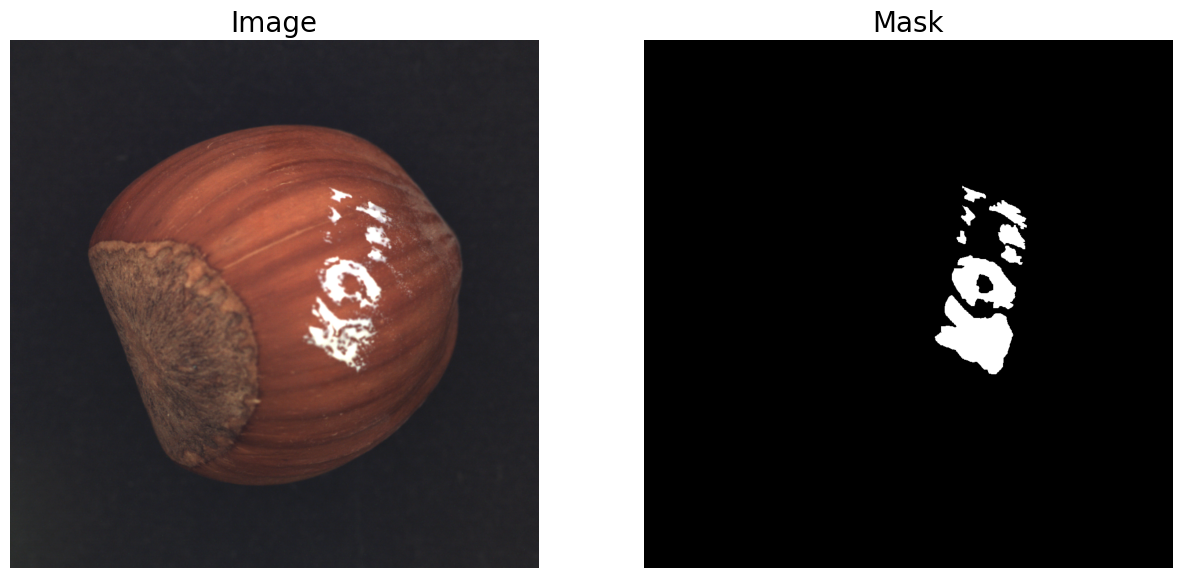

In [21]:
fig = plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)  # 2 rows, 1 columns, first position
plt.imshow(image)  
plt.axis('off')  # Hide the axis labels
plt.title("Image", fontsize = 20) 

plt.subplot(1, 2, 2)  # 2 rows, 1 columns, first position
plt.imshow(mask)  
plt.axis('off')  # Hide the axis labels
plt.title("Mask", fontsize = 20) 

plt.show()